In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')


In [ ]:
!pip install opencv-python-headless


In [ ]:
import cv2
import numpy as np
import os
import random
import shutil
import matplotlib.pyplot as plt

In [ ]:
base_path = "/content/drive/MyDrive/StegoProject"

cover_folder = os.path.join(base_path, "cover_images")
multimedia_folder = os.path.join(base_path, "multimedia_images")
stego_folder = os.path.join(base_path, "stego_images")

os.makedirs(cover_folder, exist_ok=True)
os.makedirs(multimedia_folder, exist_ok=True)
os.makedirs(stego_folder, exist_ok=True)

print("✅ Folder structure ready")

✅ Folder structure ready


In [ ]:
shutil.rmtree(stego_folder)
os.makedirs(stego_folder, exist_ok=True)

print("✅ Old stego images deleted")

✅ Old stego images deleted


In [ ]:
flags = [
    "FLAG{SQL_INJECTION}",
    "FLAG{XSS_ATTACK}",
    "PASSWORD=admin123",
    "API_KEY=XYZ123",
    "TOKEN=ABCDEF",
    "SECRET_KEY=98765",
    "AUTH=TRUE"
]

In [ ]:
def embed_lsb_sequential(image_path, secret_text, output_path): ## This function hides (embeds) secret text inside an image using LSB (Least Significant Bit) steganography.
    img = cv2.imread(image_path)      ## Loads the image from the given path , If not found → error

    if img is None:
        print("❌ Error loading:", image_path)
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  ## Converts image to single channel Easier for bit manipulation

    flat_img = img.flatten()    ## Converts 2D image → 1D array 👉 So we can modify pixels sequentially

    # 🔥 ADD STOP MARKER
    secret_text = secret_text + "#####"  ## Special marker to indicate end of hidden message Helps during extraction

    binary_secret = ''.join(format(ord(c), '08b') for c in secret_text)   ##  Each character → 8-bit binary 👉 Example: A → 01000001

    if len(binary_secret) > len(flat_img):   ## Ensures image has enough pixels to store data
        print("❌ Message too large")
        return


    for i in range(len(binary_secret)):       ##  What happens here: & 254 → clears last bit (LSB = 0) , | bit → inserts your secret bitv👉 Example:Pixel: 10101100New bit: 1 Result: 10101101
        flat_img[i] = (flat_img[i] & 254) | int(binary_secret[i])

    stego_img = flat_img.reshape(img.shape)   # Converts back to original image shape

    cv2.imwrite(output_path, stego_img)   ## Saves the stego image (with hidden data)

In [ ]:
for folder in [cover_folder, multimedia_folder]:   ## Iterates over two directories:cover_folder (original images), multimedia_folder (additional images)
    print(f"\nProcessing folder: {folder}")
    print("=" * 50)

    for img_name in os.listdir(folder):   ## Gets all filenames inside the folder and iterates over them

        if not img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
            continue

        img_path = os.path.join(folder, img_name) ## Combines folder path + filename👉 Example: /content/.../cover_images/image1.jpg

        flag = random.choice(flags)

        # 🔥 CHANGE HERE (IMPORTANT)
        name_without_ext = os.path.splitext(img_name)[0]
        output_name = f"stego_{os.path.basename(folder)}_{name_without_ext}.png"
        output_path = os.path.join(stego_folder, output_name)

        embed_lsb_sequential(img_path, flag, output_path)

        print("Injected:", img_name, "→", flag)

print("\n✅ All images processed!")


Processing folder: /content/drive/MyDrive/StegoProject/cover_images
Injected: 5673551_01d1ea993e_n.jpg → FLAG{SQL_INJECTION}
Injected: 5547758_eea9edfd54_n.jpg → TOKEN=ABCDEF
Injected: 5794835_d15905c7c8_n.jpg → API_KEY=XYZ123
Injected: 5673728_71b8cb57eb.jpg → AUTH=TRUE
Injected: 5794839_200acd910c_n.jpg → TOKEN=ABCDEF
Injected: 8475758_4c861ab268_m.jpg → PASSWORD=admin123
Injected: 8223968_6b51555d2f_n.jpg → FLAG{XSS_ATTACK}
Injected: 7355522_b66e5d3078_m.jpg → AUTH=TRUE
Injected: 8181477_8cb77d2e0f_n.jpg → API_KEY=XYZ123
Injected: 8223949_2928d3f6f6_n.jpg → SECRET_KEY=98765
Injected: 1.jpg → AUTH=TRUE
Injected: pexels-yelenaodintsova-16197836.jpg → API_KEY=XYZ123
Injected: pexels-delot-15127741.jpg → PASSWORD=admin123
Injected: pexels-rodolfoclix-1581711.jpg → FLAG{SQL_INJECTION}
Injected: pexels-david-sun-345764-955086.jpg → TOKEN=ABCDEF
Injected: pexels-gustavo-medeiros-109551-3929964.jpg → PASSWORD=admin123
Injected: input.jpg → PASSWORD=admin123
Injected: pexels-kpaukshtite-112

In [ ]:
def extract_lsb_sequential(stego_path):  ## This function extracts hidden text from a stego image using LSB technique.
    img = cv2.imread(stego_path, cv2.IMREAD_GRAYSCALE) ## Loads the image in grayscale , 👉 Ensures single channel for bit extraction

    if img is None:
        return None

    flat_img = img.flatten()   ## Converts image into 1D array 👉 Makes sequential processing easier

    binary_data = ""   ## Empty string to store extracted bits
    for pixel in flat_img:   ## For each pixel:pixel & 1 extracts last bit (LSB) Adds it to binary string. 👉 Example: Pixel: 10101101 → LSB = 1
        binary_data += str(pixel & 1)

    chars = []   ## List to store decoded characters
    for i in range(0, len(binary_data), 8):   ## Process binary in chunks of 8 bits (1 byte)
        byte = binary_data[i:i+8]   ## Extract one byte

        if len(byte) < 8:   ## Ignore incomplete byte at end
            break

        char = chr(int(byte, 2))   ## 👉 Converts binary → decimal → ASCII character
        chars.append(char)     ## 👉 Add character to list

        # 🔥 STOP WHEN MARKER FOUND
        if ''.join(chars).endswith("#####"):    ## 👉 Checks if stop marker is reached
            return ''.join(chars).replace("#####", "")    ## Returns extracted message 👉 Removes marker

    return None   ## no hidden data or corrupted data

In [ ]:
## EXTRACTION

In [ ]:
print("\n🔍 Extracting Flags...\n")

for img_name in os.listdir(stego_folder):

    if not img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
        continue

    img_path = os.path.join(stego_folder, img_name)

    flag = extract_lsb_sequential(img_path)

    if flag:
        print(f"✅ {img_name} → {flag}")
    else:
        print(f"❌ No flag in {img_name}")


🔍 Extracting Flags...

✅ stego_cover_images_5673551_01d1ea993e_n.png → FLAG{SQL_INJECTION}
✅ stego_cover_images_5547758_eea9edfd54_n.png → TOKEN=ABCDEF
✅ stego_cover_images_5794835_d15905c7c8_n.png → API_KEY=XYZ123
✅ stego_cover_images_5673728_71b8cb57eb.png → AUTH=TRUE
✅ stego_cover_images_5794839_200acd910c_n.png → TOKEN=ABCDEF
✅ stego_cover_images_8475758_4c861ab268_m.png → PASSWORD=admin123
✅ stego_cover_images_8223968_6b51555d2f_n.png → FLAG{XSS_ATTACK}
✅ stego_cover_images_7355522_b66e5d3078_m.png → AUTH=TRUE
✅ stego_cover_images_8181477_8cb77d2e0f_n.png → API_KEY=XYZ123
✅ stego_cover_images_8223949_2928d3f6f6_n.png → SECRET_KEY=98765
✅ stego_cover_images_1.png → AUTH=TRUE
✅ stego_cover_images_pexels-yelenaodintsova-16197836.png → API_KEY=XYZ123
✅ stego_cover_images_pexels-delot-15127741.png → PASSWORD=admin123
✅ stego_cover_images_pexels-rodolfoclix-1581711.png → FLAG{SQL_INJECTION}
✅ stego_cover_images_pexels-david-sun-345764-955086.png → TOKEN=ABCDEF
✅ stego_cover_images_pexe

## Machine Learning (Steganalysis)

# 👉 Goal:
# Detect whether an image contains hidden data

In [ ]:
## STEP 1 — Create Dataset Structure
import os
import shutil
import random

base_ml = "/content/drive/MyDrive/StegoProject/ml_dataset"

train_clean = os.path.join(base_ml, "train/clean")
train_stego = os.path.join(base_ml, "train/stego")
test_clean = os.path.join(base_ml, "test/clean")
test_stego = os.path.join(base_ml, "test/stego")

for path in [train_clean, train_stego, test_clean, test_stego]:
    os.makedirs(path, exist_ok=True)

print("✅ Dataset folders created")

✅ Dataset folders created


In [ ]:
## STEP 2 — Split Data (Train/Test)
cover_images = os.listdir(cover_folder)
stego_images = os.listdir(stego_folder)

random.shuffle(cover_images)
random.shuffle(stego_images)

split_ratio = 0.8

split_clean = int(len(cover_images) * split_ratio)
split_stego = int(len(stego_images) * split_ratio)

In [ ]:
##STEP 3 — Copy Images to Dataset

# CLEAN IMAGES
for img in cover_images[:split_clean]:
    shutil.copy(os.path.join(cover_folder, img), train_clean)

for img in cover_images[split_clean:]:
    shutil.copy(os.path.join(cover_folder, img), test_clean)

# STEGO IMAGES
for img in stego_images[:split_stego]:
    shutil.copy(os.path.join(stego_folder, img), train_stego)

for img in stego_images[split_stego:]:
    shutil.copy(os.path.join(stego_folder, img), test_stego)

print("✅ Dataset prepared")

✅ Dataset prepared


In [ ]:
## STEP 4 — Load Dataset (TensorFlow)

import tensorflow as tf

img_size = (128, 128)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_ml + "/train",
    image_size=img_size,
    batch_size=batch_size
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_ml + "/test",
    image_size=img_size,
    batch_size=batch_size
)

Found 303 files belonging to 2 classes.
Found 76 files belonging to 2 classes.


In [ ]:
## STEP 5 — Normalize Data
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
##  STEP 6 — Build CNN Model

from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
## STEP 7 — Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
## STEP 8 — Train Model

history = model.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds
)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.7162 - loss: 0.6556 - val_accuracy: 0.8026 - val_loss: 0.5393
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step - accuracy: 0.8020 - loss: 0.5575 - val_accuracy: 0.8026 - val_loss: 0.4686
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.8053 - loss: 0.4938 - val_accuracy: 0.8289 - val_loss: 0.4024
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.8416 - loss: 0.4118 - val_accuracy: 0.8947 - val_loss: 0.2610
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.8911 - loss: 0.3273 - val_accuracy: 0.9737 - val_loss: 0.1280


In [ ]:
## STEP 9 — Evaluate Model
loss, accuracy = model.evaluate(test_ds)

print(f"\n🎯 Accuracy: {accuracy * 100:.2f}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9737 - loss: 0.1280

🎯 Accuracy: 97.37%


In [ ]:
## STEP 10 — Predictions (Demo)
import numpy as np

class_names = ["Clean", "Stego"]

for images, labels in test_ds.take(1):
    preds = model.predict(images)

    for i in range(5):
        pred_label = 1 if preds[i] > 0.5 else 0
        print("Actual:", class_names[int(labels[i])],
              "| Predicted:", class_names[pred_label])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
Actual: Stego | Predicted: Stego
Actual: Stego | Predicted: Stego
Actual: Stego | Predicted: Stego
Actual: Stego | Predicted: Stego
Actual: Stego | Predicted: Stego


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 586ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Confusion Matrix:
[[13  2]
 [ 0 61]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        15
           1       0.97      1.00      0.98        61

    accuracy                           0.97        76
   macro avg       0.98      0.93      0.96        76
weighted avg       0.97      0.97      0.97        76



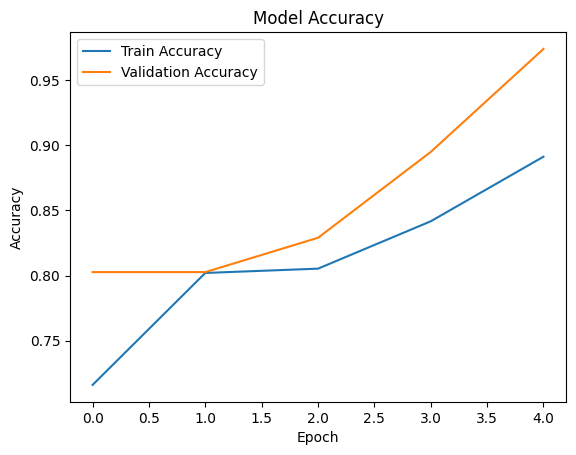

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Accuracy")
plt.show()

Attack Simulation (CYBERSECURITY LEVEL)
🚀 WHAT IS “ATTACK SIMULATION”?

👉 You show:

Role	Action
🧑‍💻 Attacker	Hide malicious data in images
🛡️ Defender	Detect + extract hidden data


[Attacker]
->
Embed malicious payload in image
->
Send image (looks normal)
->
[Defender]
->
ML detects stego image
->
Extract hidden payload

In [ ]:
## STEP 1 — Define Malicious Payloads
malicious_payloads = [
    "SQL: ' OR 1=1 --",
    "XSS: <script>alert('hack')</script>",
    "CMD: rm -rf /",
    "API_KEY: sk_live_ABC123",
    "PASSWORD: root@123",
    "IP: 192.168.0.10 PORT:4444",
    "TOKEN: admin_access_granted"
]

In [ ]:
## STEP 2 — Attacker Embeds Payload
for img_name in os.listdir(cover_folder):

    if not img_name.lower().endswith(('.jpg', '.png')):
        continue

    img_path = os.path.join(cover_folder, img_name)

    payload = random.choice(malicious_payloads)

    output_name = "attack_" + os.path.splitext(img_name)[0] + ".png"
    output_path = os.path.join(stego_folder, output_name)

    embed_lsb_sequential(img_path, payload, output_path)

    print("⚠️ Attack injected:", payload)

⚠️ Attack injected: TOKEN: admin_access_granted
⚠️ Attack injected: PASSWORD: root@123
⚠️ Attack injected: CMD: rm -rf /
⚠️ Attack injected: IP: 192.168.0.10 PORT:4444
⚠️ Attack injected: TOKEN: admin_access_granted
⚠️ Attack injected: IP: 192.168.0.10 PORT:4444
⚠️ Attack injected: TOKEN: admin_access_granted
⚠️ Attack injected: PASSWORD: root@123
⚠️ Attack injected: TOKEN: admin_access_granted
⚠️ Attack injected: SQL: ' OR 1=1 --
⚠️ Attack injected: CMD: rm -rf /
⚠️ Attack injected: IP: 192.168.0.10 PORT:4444
⚠️ Attack injected: TOKEN: admin_access_granted
⚠️ Attack injected: TOKEN: admin_access_granted
⚠️ Attack injected: PASSWORD: root@123
⚠️ Attack injected: API_KEY: sk_live_ABC123
⚠️ Attack injected: API_KEY: sk_live_ABC123
⚠️ Attack injected: IP: 192.168.0.10 PORT:4444
⚠️ Attack injected: IP: 192.168.0.10 PORT:4444
⚠️ Attack injected: TOKEN: admin_access_granted
⚠️ Attack injected: API_KEY: sk_live_ABC123
⚠️ Attack injected: IP: 192.168.0.10 PORT:4444
⚠️ Attack injected: TOKEN: a

In [ ]:
def predict_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (128,128))
    img = np.expand_dims(img / 255.0, axis=0)

    pred = model.predict(img)[0][0]

    return "STEGO (ATTACK)" if pred > 0.5 else "CLEAN"

In [ ]:
## STEP 4 — Detect + Extract Attack

for img_name in os.listdir(stego_folder):

    if not img_name.endswith(".png"):
        continue

    img_path = os.path.join(stego_folder, img_name)

    result = predict_image(img_path)

    print(f"\nImage: {img_name}")
    print("Detection:", result)

    if result == "STEGO (ATTACK)":
        payload = extract_lsb_sequential(img_path)
        print("⚠️ Extracted Payload:", payload)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Image: stego_cover_images_5673551_01d1ea993e_n.png
Detection: STEGO (ATTACK)
⚠️ Extracted Payload: FLAG{SQL_INJECTION}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

Image: stego_cover_images_5547758_eea9edfd54_n.png
Detection: STEGO (ATTACK)
⚠️ Extracted Payload: TOKEN=ABCDEF
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Image: stego_cover_images_5794835_d15905c7c8_n.png
Detection: STEGO (ATTACK)
⚠️ Extracted Payload: API_KEY=XYZ123
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

Image: stego_cover_images_5673728_71b8cb57eb.png
Detection: STEGO (ATTACK)
⚠️ Extracted Payload: AUTH=TRUE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Image: stego_cover_images_5794839_200acd910c_n.png
Detection: STEGO (ATTACK)
⚠️ Extracted Payload: TOKEN=ABCDEF
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Image: stego_cover_images_8475758_4c861ab268_m.png
Detection: STEGO (ATTACK)
⚠️ Extracted Payload: PASSWORD=admin123
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

Image: stego_cover_images_8223968_6b51555d2f_n

In [ ]:
## Show Original vs Attack Image

orig = cv2.imread(original_path)
attack = cv2.imread(stego_path)

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(attack, cv2.COLOR_BGR2RGB))
plt.title("Attack Image")

plt.show()

NameError: name 'original_path' is not defined

encryption before embedding

In [ ]:
## CELL 1 — Encryption Functions (NEW)
def encrypt(text, key=123):
    return ''.join(chr(ord(c) ^ key) for c in text)

def decrypt(text, key=123):
    return ''.join(chr(ord(c) ^ key) for c in text)

In [ ]:
## CELL 2 — Embedding Function (UNCHANGED)
def embed_lsb_sequential(image_path, secret_text, output_path):
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Error loading:", image_path)
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    flat_img = img.flatten()

    # Add marker
    secret_text = secret_text + "#####"

    binary_secret = ''.join(format(ord(c), '08b') for c in secret_text)

    if len(binary_secret) > len(flat_img):
        print("❌ Message too large")
        return

    for i in range(len(binary_secret)):
        flat_img[i] = (flat_img[i] & 254) | int(binary_secret[i])

    stego_img = flat_img.reshape(img.shape)

    cv2.imwrite(output_path, stego_img)

In [ ]:
## CELL 3 — 🔥 EMBEDDING WITH ENCRYPTION

for folder in [cover_folder, multimedia_folder]:
    print(f"\nProcessing folder: {folder}")
    print("=" * 50)

    for img_name in os.listdir(folder):

        if not img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
            continue

        img_path = os.path.join(folder, img_name)

        # Select flag
        flag = random.choice(flags)

        # 🔐 Encrypt flag
        encrypted_flag = encrypt(flag)

        # Save as PNG
        name_without_ext = os.path.splitext(img_name)[0]
        output_name = f"stego_{os.path.basename(folder)}_{name_without_ext}.png"
        output_path = os.path.join(stego_folder, output_name)

        embed_lsb_sequential(img_path, encrypted_flag, output_path)

        print("Original:", flag)
        print("Encrypted:", encrypted_flag)
        print("-" * 40)

print("\n✅ All images processed!")


Processing folder: /content/drive/MyDrive/StegoProject/cover_images
Original: SECRET_KEY=98765
Encrypted: (>8)>/$0>"FBCLMN
----------------------------------------
Original: API_KEY=XYZ123
Encrypted: :+2$0>"F#"!JIH
----------------------------------------
Original: API_KEY=XYZ123
Encrypted: :+2$0>"F#"!JIH
----------------------------------------
Original: SECRET_KEY=98765
Encrypted: (>8)>/$0>"FBCLMN
----------------------------------------
Original: API_KEY=XYZ123
Encrypted: :+2$0>"F#"!JIH
----------------------------------------
Original: SECRET_KEY=98765
Encrypted: (>8)>/$0>"FBCLMN
----------------------------------------
Original: FLAG{XSS_ATTACK}
Encrypted: =7:< #(($://:80
----------------------------------------
Original: FLAG{SQL_INJECTION}
Encrypted: =7:< (*7$251>8/245
----------------------------------------
Original: FLAG{SQL_INJECTION}
Encrypted: =7:< (*7$251>8/245
----------------------------------------
Original: SECRET_KEY=98765
Encrypted: (>8)>/$0>"FBCLMN
------------

In [ ]:
##CELL 4 — Extraction Function
def extract_lsb_sequential(stego_path):
    img = cv2.imread(stego_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None

    flat_img = img.flatten()

    binary_data = ""
    for pixel in flat_img:
        binary_data += str(pixel & 1)

    chars = []
    for i in range(0, len(binary_data), 8):
        byte = binary_data[i:i+8]

        if len(byte) < 8:
            break

        char = chr(int(byte, 2))
        chars.append(char)

        if ''.join(chars).endswith("#####"):
            return ''.join(chars).replace("#####", "")

    return None

In [ ]:
## CELL 5 — 🔥 EXTRACTION + DECRYPTION

print("\n🔍 Extracting & Decrypting Flags...\n")

for img_name in os.listdir(stego_folder):

    if not img_name.lower().endswith(('.png',)):
        continue

    img_path = os.path.join(stego_folder, img_name)

    encrypted_flag = extract_lsb_sequential(img_path)

    if encrypted_flag:
        decrypted_flag = decrypt(encrypted_flag)

        print(f"🖼 Image: {img_name}")
        print("🔐 Encrypted:", encrypted_flag)
        print("🔓 Decrypted:", decrypted_flag)
        print("=" * 60)
    else:
        print(f"❌ No flag in {img_name}")


🔍 Extracting & Decrypting Flags...

🖼 Image: stego_cover_images_5673551_01d1ea993e_n.png
🔐 Encrypted: (>8)>/$0>"FBCLMN
🔓 Decrypted: SECRET_KEY=98765
🖼 Image: stego_cover_images_5547758_eea9edfd54_n.png
🔐 Encrypted: :+2$0>"F#"!JIH
🔓 Decrypted: API_KEY=XYZ123
🖼 Image: stego_cover_images_5794835_d15905c7c8_n.png
🔐 Encrypted: :+2$0>"F#"!JIH
🔓 Decrypted: API_KEY=XYZ123
🖼 Image: stego_cover_images_5673728_71b8cb57eb.png
🔐 Encrypted: (>8)>/$0>"FBCLMN
🔓 Decrypted: SECRET_KEY=98765
🖼 Image: stego_cover_images_5794839_200acd910c_n.png
🔐 Encrypted: :+2$0>"F#"!JIH
🔓 Decrypted: API_KEY=XYZ123
🖼 Image: stego_cover_images_8475758_4c861ab268_m.png
🔐 Encrypted: (>8)>/$0>"FBCLMN
🔓 Decrypted: SECRET_KEY=98765
🖼 Image: stego_cover_images_8223968_6b51555d2f_n.png
🔐 Encrypted: =7:< #(($://:80
🔓 Decrypted: FLAG{XSS_ATTACK}
🖼 Image: stego_cover_images_7355522_b66e5d3078_m.png
🔐 Encrypted: =7:< (*7$251>8/245
🔓 Decrypted: FLAG{SQL_INJECTION}
🖼 Image: stego_cover_images_8181477_8cb77d2e0f_n.png
🔐 Encrypted: =

KeyboardInterrupt: 

In [ ]:
# Step 1: pick one stego image
stego_name = os.listdir(stego_folder)[0]

# Step 2: build stego path
stego_path = os.path.join(stego_folder, stego_name)

# Step 3: extract original name
name = stego_name.replace("stego_cover_images_", "").replace("stego_multimedia_images_", "")
name = os.path.splitext(name)[0]

# Step 4: find original image (auto detect extension)
orig_path = None

for ext in ['.jpg', '.png', '.jpeg']:
    possible_path = os.path.join(cover_folder, name + ext)
    if os.path.exists(possible_path):
        orig_path = possible_path
        break

print("Stego:", stego_path)
print("Original:", orig_path)

Stego: /content/drive/MyDrive/StegoProject/stego_images/stego_cover_images_5673551_01d1ea993e_n.png
Original: /content/drive/MyDrive/StegoProject/cover_images/5673551_01d1ea993e_n.jpg


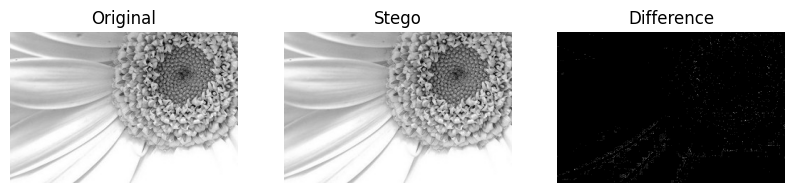

In [ ]:
## “Although the stego image looks identical to the original, the difference image reveals subtle
## pixel-level changes caused by LSB embedding. This proves that hidden data exists even though it is not visible to the human eye.”

orig = cv2.imread(orig_path, 0)
stego = cv2.imread(stego_path, 0)

diff = cv2.absdiff(orig, stego) * 10
lsb = (stego & 1) * 255

plt.figure(figsize=(10,6))

plt.subplot(1,3,1)
plt.imshow(orig, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(stego, cmap='gray')
plt.title("Stego")

plt.subplot(1,3,3)
plt.imshow(diff, cmap='gray')
plt.title("Difference")

for i in range(1,4):
    plt.subplot(1,3,i).axis('off')

plt.show()


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

orig = cv2.imread(orig_path, 0)
stego = cv2.imread(stego_path, 0)

if orig is None or stego is None:
    print("❌ Error loading images")
else:
    print("✅ Images loaded successfully")

✅ Images loaded successfully


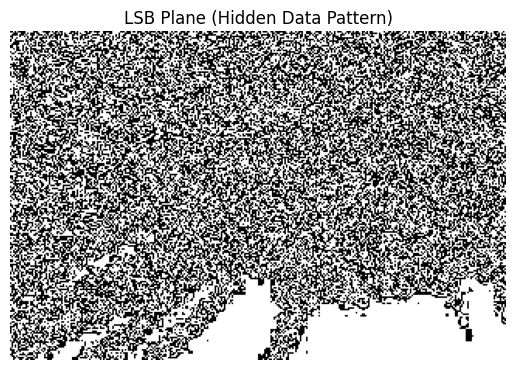

In [ ]:
## The LSB plane shows a random noise pattern, which confirms the presence of hidden data.
##The randomness is due to encryption, making the embedded information more secure and harder to detect.”

lsb = (stego & 1) * 255

plt.imshow(lsb, cmap='gray')
plt.title("LSB Plane (Hidden Data Pattern)")
plt.axis('off')
plt.show()

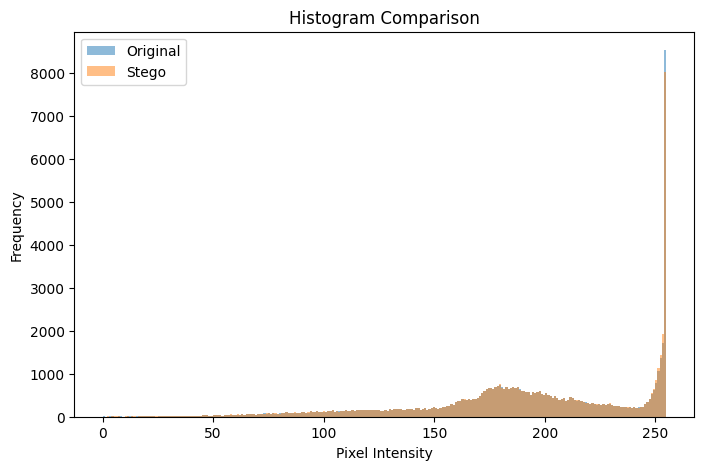

In [ ]:
## The histogram comparison shows that steganographic embedding does not significantly alter the statistical distribution of pixel intensities,
## making it difficult to detect using simple visual or statistical methods.”

plt.figure(figsize=(8,5))

plt.hist(orig.ravel(), bins=256, alpha=0.5, label='Original')
plt.hist(stego.ravel(), bins=256, alpha=0.5, label='Stego')

plt.legend()
plt.title("Histogram Comparison")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

In [ ]:
mse = np.mean((orig - stego) ** 2)

if mse == 0:
    psnr = 100
else:
    psnr = 20 * np.log10(255.0 / np.sqrt(mse))

print("📊 MSE:", mse)
print("📊 PSNR:", psnr)

📊 MSE: 0.07246462264150944
📊 PSNR: 59.529543259021516


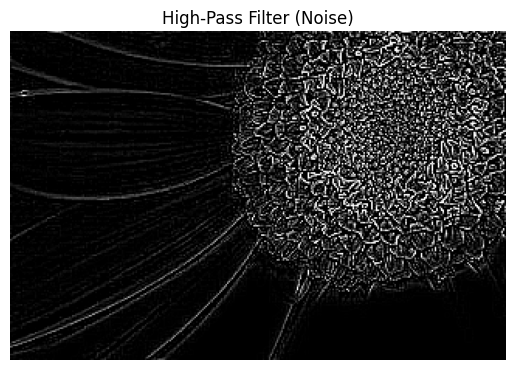

In [ ]:
## A high-pass filter extracts high-frequency components like edges and noise from an image.
## The high-pass filter enhances high-frequency components, exposing noise patterns caused by hidden data embedding, which helps in steganalysis.”
# Observation:
# Edges are clearly visible
# Texture appears more detailed
# Some regions show extra noise patterns

kernel = np.array([[-1,-1,-1],
                   [-1, 8,-1],
                   [-1,-1,-1]])

high_pass = cv2.filter2D(stego, -1, kernel)

plt.imshow(high_pass, cmap='gray')
plt.title("High-Pass Filter (Noise)")
plt.axis('off')
plt.show()

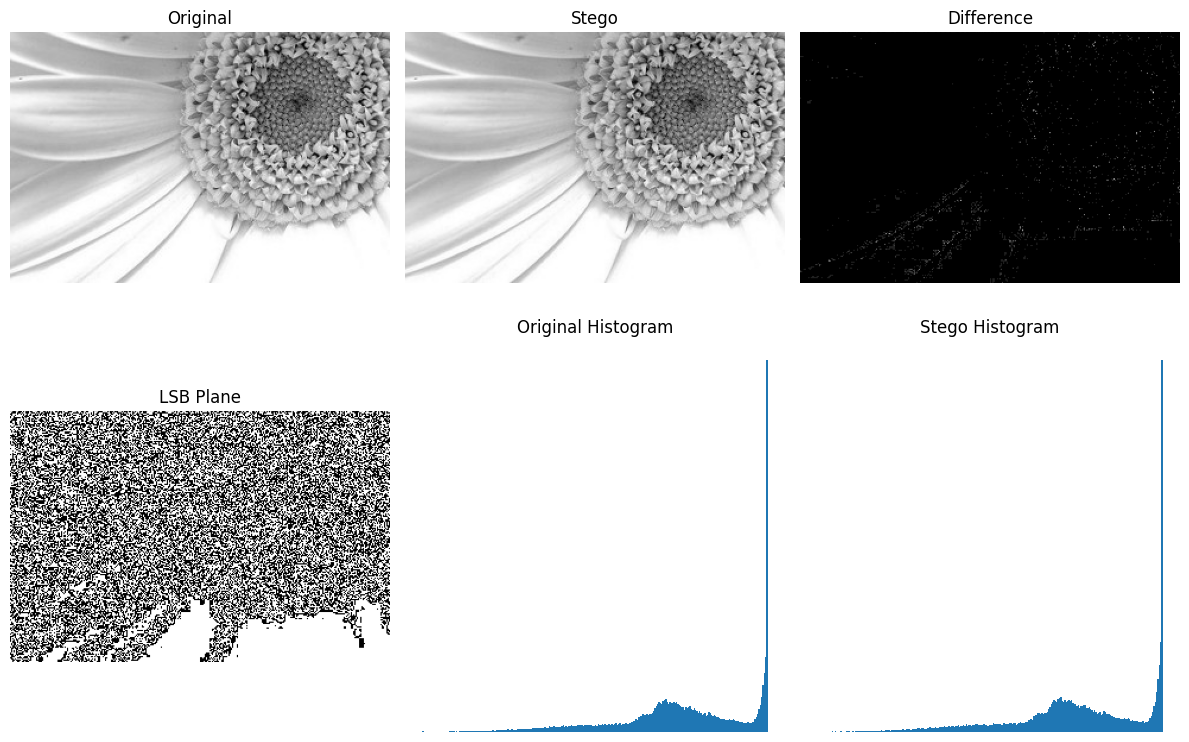

In [ ]:
diff = cv2.absdiff(orig, stego) * 10
lsb = (stego & 1) * 255

plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(orig, cmap='gray')
plt.title("Original")

plt.subplot(2,3,2)
plt.imshow(stego, cmap='gray')
plt.title("Stego")

plt.subplot(2,3,3)
plt.imshow(diff, cmap='gray')
plt.title("Difference")

plt.subplot(2,3,4)
plt.imshow(lsb, cmap='gray')
plt.title("LSB Plane")

plt.subplot(2,3,5)
plt.hist(orig.ravel(), bins=256)
plt.title("Original Histogram")

plt.subplot(2,3,6)
plt.hist(stego.ravel(), bins=256)
plt.title("Stego Histogram")

for i in range(1,7):
    plt.subplot(2,3,i).axis('off')

plt.tight_layout()
plt.show()

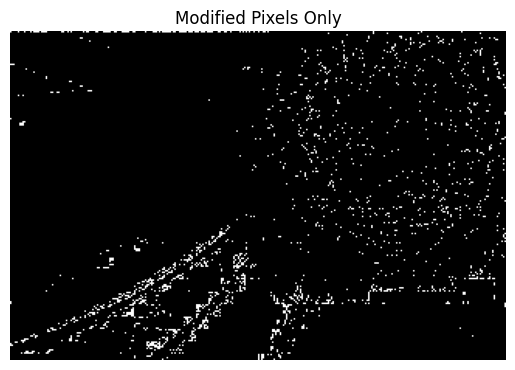

In [ ]:
## These white dots represent the exact locations where data has been embedded.”
## Highlight ONLY modified pixels
mask = (orig != stego).astype(np.uint8) * 255

plt.imshow(mask, cmap='gray')
plt.title("Modified Pixels Only")
plt.axis('off')
plt.show()

In [ ]:
## Percentage of Pixels Modified

total_pixels = orig.size
modified_pixels = np.sum(orig != stego)

percentage = (modified_pixels / total_pixels) * 100

print("Modified Pixels:", modified_pixels)
print("Total Pixels:", total_pixels)
print(f"Percentage Modified: {percentage:.4f}%")

Modified Pixels: 1968
Total Pixels: 67840
Percentage Modified: 2.9009%


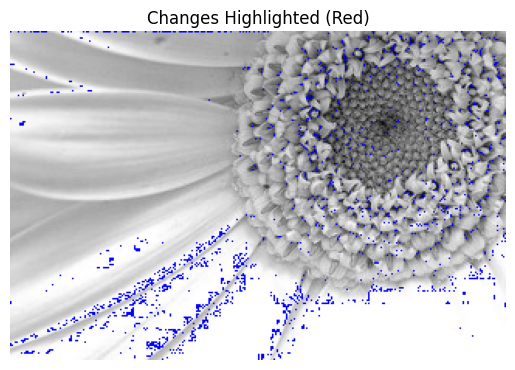

In [ ]:
## Overlay Changes on Image
## This visualization clearly shows that steganography modifies only a small number of pixels, while keeping the overall image visually unchanged.
## verlay visualization provides a clear and intuitive way to identify modified pixels, showing how hidden data is distributed across the image without affecting visual quality.”
overlay = cv2.cvtColor(orig, cv2.COLOR_GRAY2BGR)

overlay[orig != stego] = [0, 0, 255]  # red highlights

plt.imshow(overlay)
plt.title("Changes Highlighted (Red)")
plt.axis('off')
plt.show()

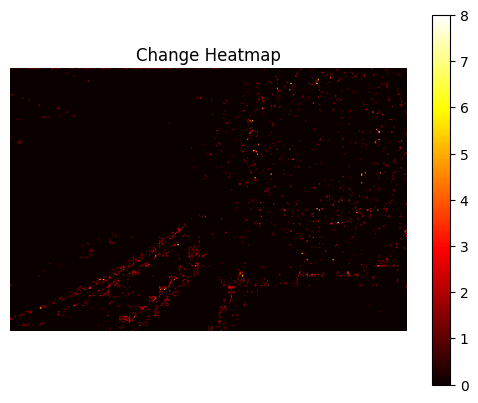

In [ ]:
## Heatmap Visualization
heatmap = cv2.absdiff(orig, stego)

plt.imshow(heatmap, cmap='hot')
plt.colorbar()
plt.title("Change Heatmap")
plt.axis('off')
plt.show()

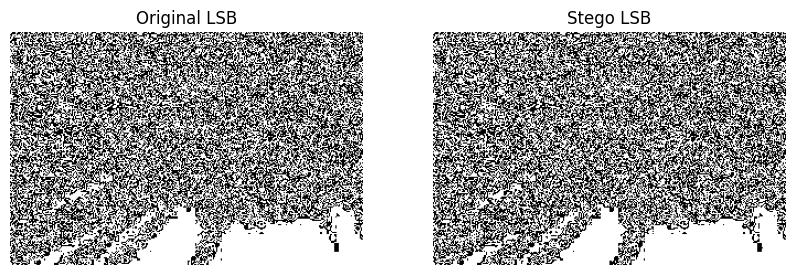

In [ ]:
## Compare Clean vs Stego LSB

orig_lsb = (orig & 1) * 255
stego_lsb = (stego & 1) * 255

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(orig_lsb, cmap='gray')
plt.title("Original LSB")

plt.subplot(1,2,2)
plt.imshow(stego_lsb, cmap='gray')
plt.title("Stego LSB")

for i in range(1,3):
    plt.subplot(1,2,i).axis('off')

plt.show()